### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering, SpectralClustering

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

import scipy.cluster.hierarchy as sch

from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score

import warnings
warnings.filterwarnings('ignore')

### Просмотр набора данных

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()

In [3]:
iris_df = pd.DataFrame(iris.data)

In [4]:
# Делаем имена колонок такие же, как имена переменных:
iris_df.columns = iris.feature_names
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [6]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Идентификация корреляций между переменными

<Axes: >

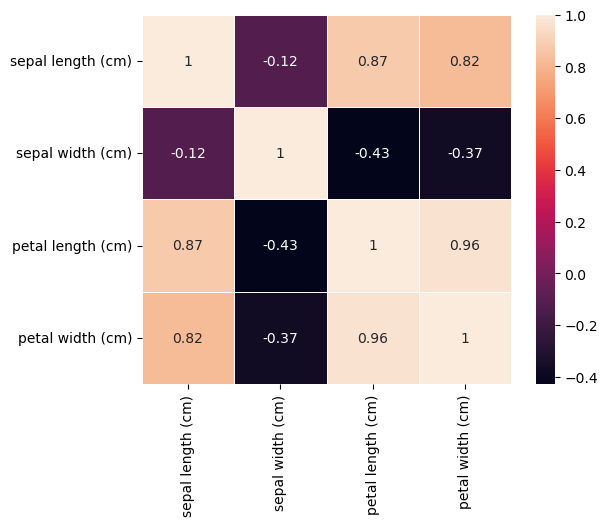

In [7]:
sns.heatmap(iris_df.corr(), square=True, annot=True, linewidths=.5)

### Нормализация

In [8]:
mms = MinMaxScaler()
iris_df=pd.DataFrame(mms.fit_transform(iris_df), columns=iris_df.columns)

### Метод главных компонентов

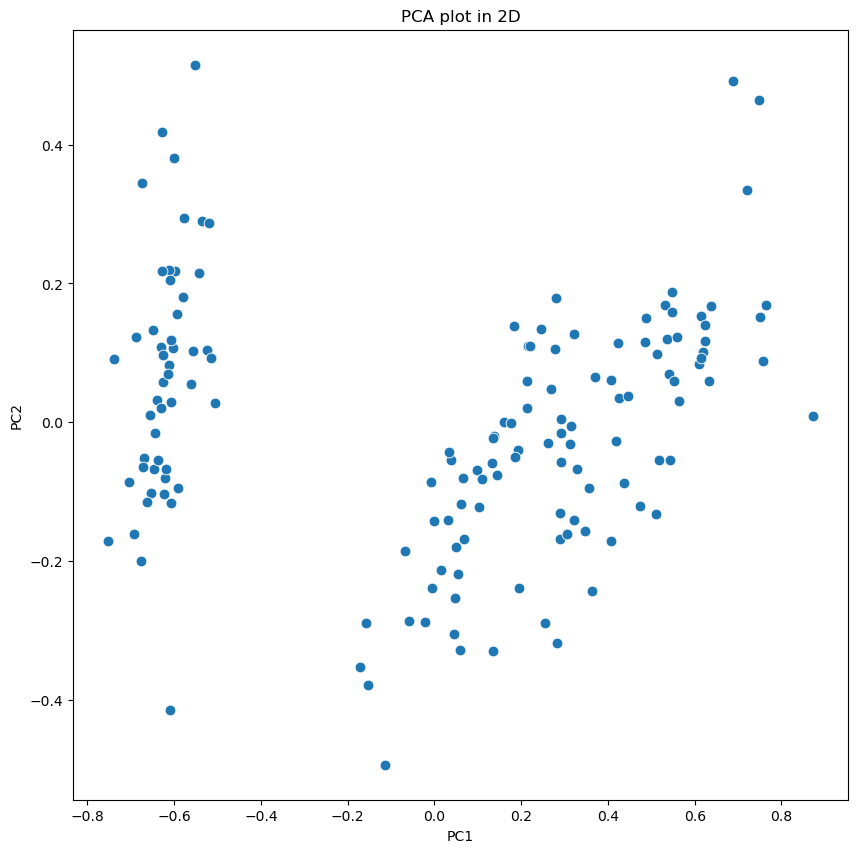

In [9]:
principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(iris_df))
    
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                s=60)

plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

In [10]:
def TSNEplot(pred=None):    
    tsne = TSNE(random_state=1)
    X_tsne = tsne.fit_transform(iris_df)

    plt.figure(figsize=(12, 10))
    plt.scatter(X_tsne[:, 0], 
                X_tsne[:, 1], 
                c = pred, 
                edgecolor="none", 
                alpha=0.7, s=40,
        cmap=plt.cm.get_cmap("flare", 3))

    plt.colorbar()
    plt.title("t-SNE projection");

  File "C:\Users\robhul\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\robhul\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\robhul\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\robhul\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


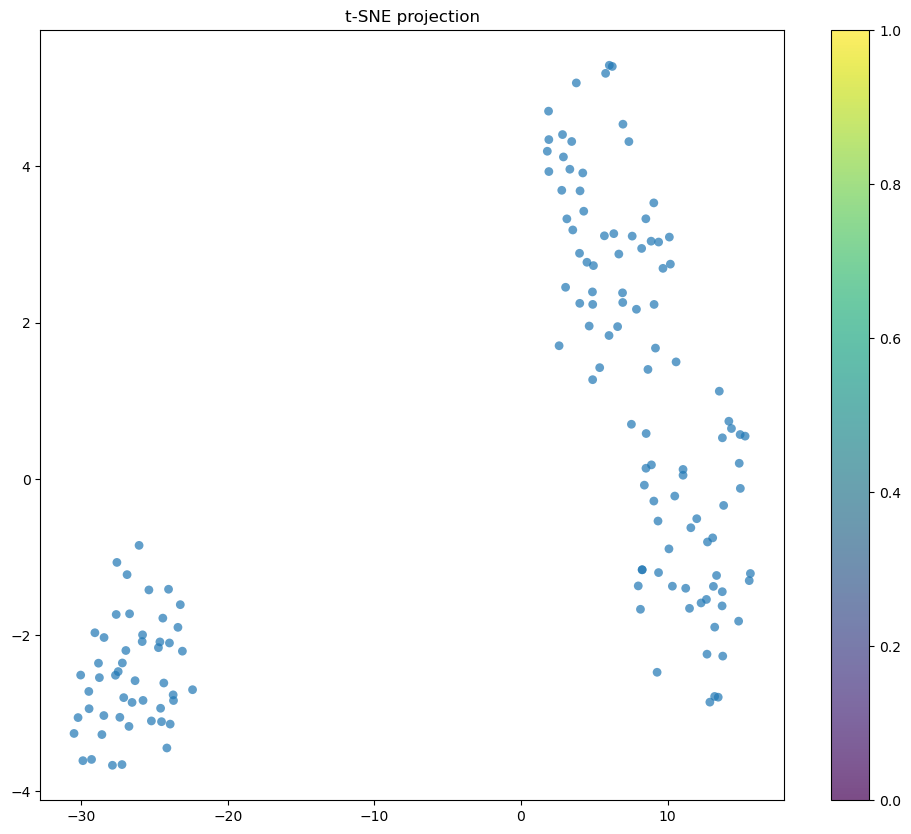

In [11]:
TSNEplot()

# K-Means

In [12]:
pca = PCA(n_components=2)

kmeans = KMeans(n_clusters=3, random_state=1, n_init='auto').fit(iris_df)
centroids_pca = pca.fit_transform(kmeans.cluster_centers_)
pred_k = kmeans.labels_

principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(iris_df))

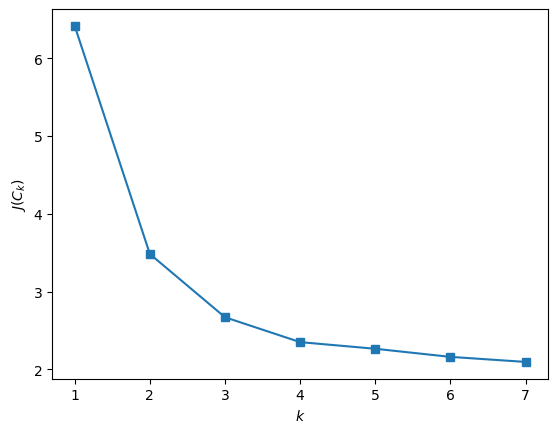

In [13]:
inertia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=1, n_init='auto').fit(iris_df)
    inertia.append(np.sqrt(kmeans.inertia_))
    
plt.plot(range(1, 8), inertia, marker="s")
plt.xlabel("$k$")
plt.ylabel("$J(C_k)$");

In [14]:
pca = PCA(n_components=2)


kmeans = KMeans(n_clusters=3, random_state=1, n_init='auto').fit(iris_df)
centroids_pca = pca.fit_transform(kmeans.cluster_centers_)
pred_k = kmeans.labels_

principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(iris_df))

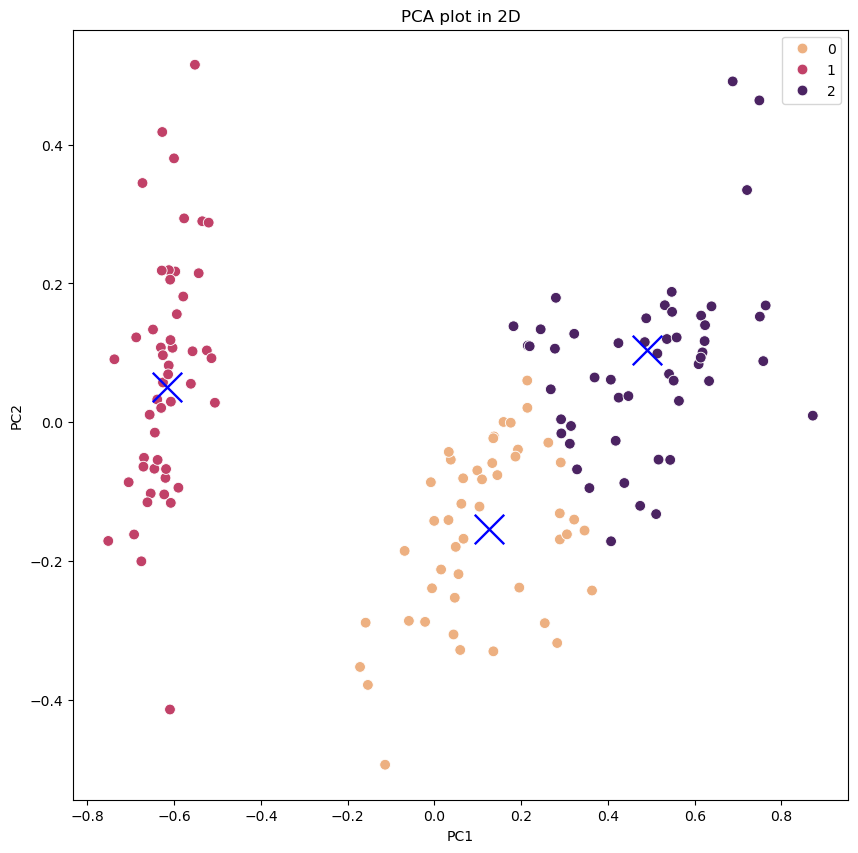

In [15]:
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_k, 
                palette="flare", 
                s=60)
sns.scatterplot(x = centroids_pca[:,0], 
                y =  centroids_pca[:,1],  
                marker="x", 
                s=450, 
                color = 'blue')
plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

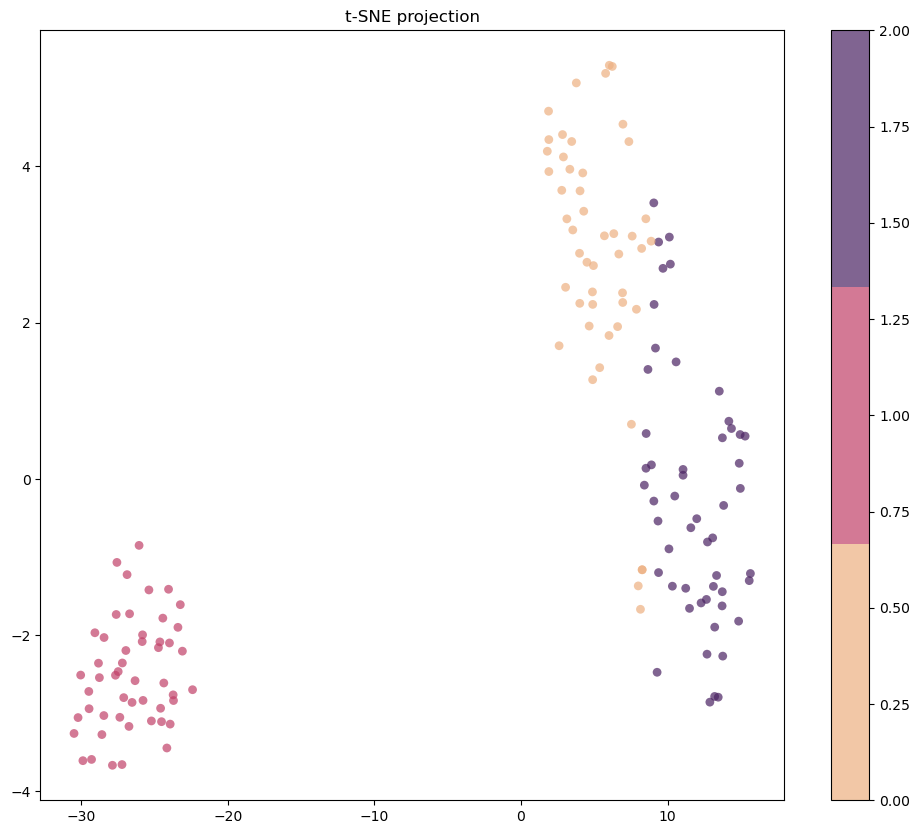

In [16]:
TSNEplot(pred_k)

# Agglomerative Clustering by Ward

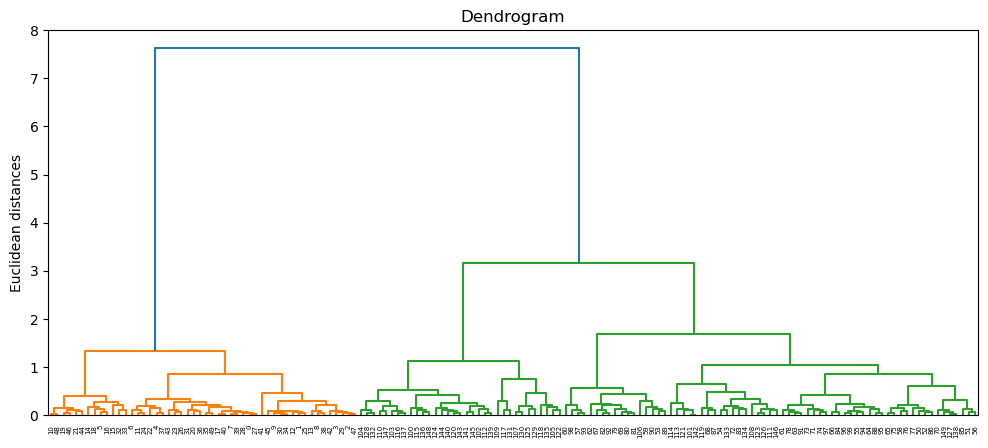

In [17]:
plt.figure(figsize=(12, 5))
dendrogram = sch.dendrogram(sch.linkage(iris_df, method = 'ward'))
plt.title('Dendrogram')
plt.ylabel('Euclidean distances')
plt.show()

In [18]:
clustering_ward = AgglomerativeClustering(3).fit(iris_df)
pred_ward = clustering_ward.labels_

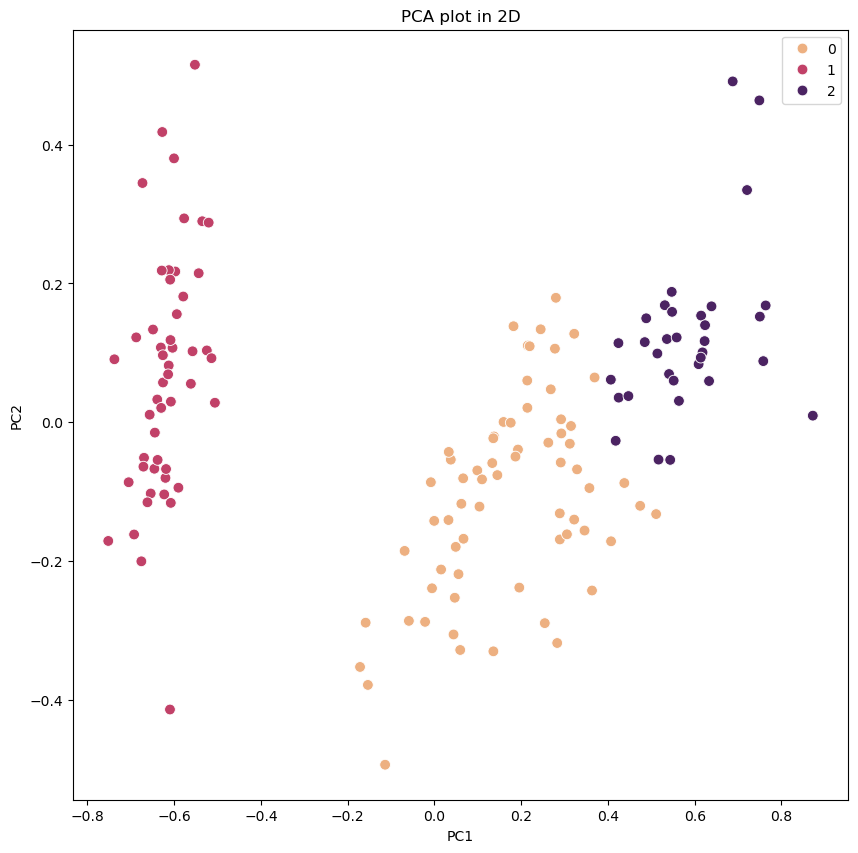

In [19]:
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_ward, 
                palette="flare", 
                s=60)
plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

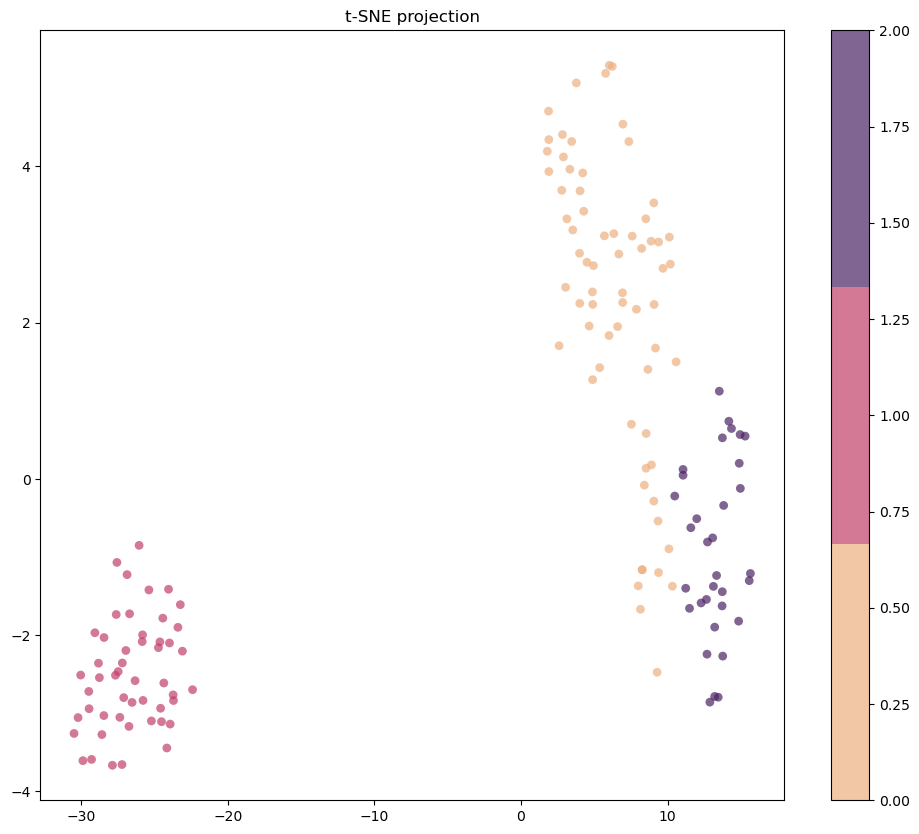

In [20]:
TSNEplot(pred_ward)

# Spectral Clustering

In [21]:
clustering_sp = SpectralClustering(3).fit(iris_df)
pred_sp = clustering_sp.labels_

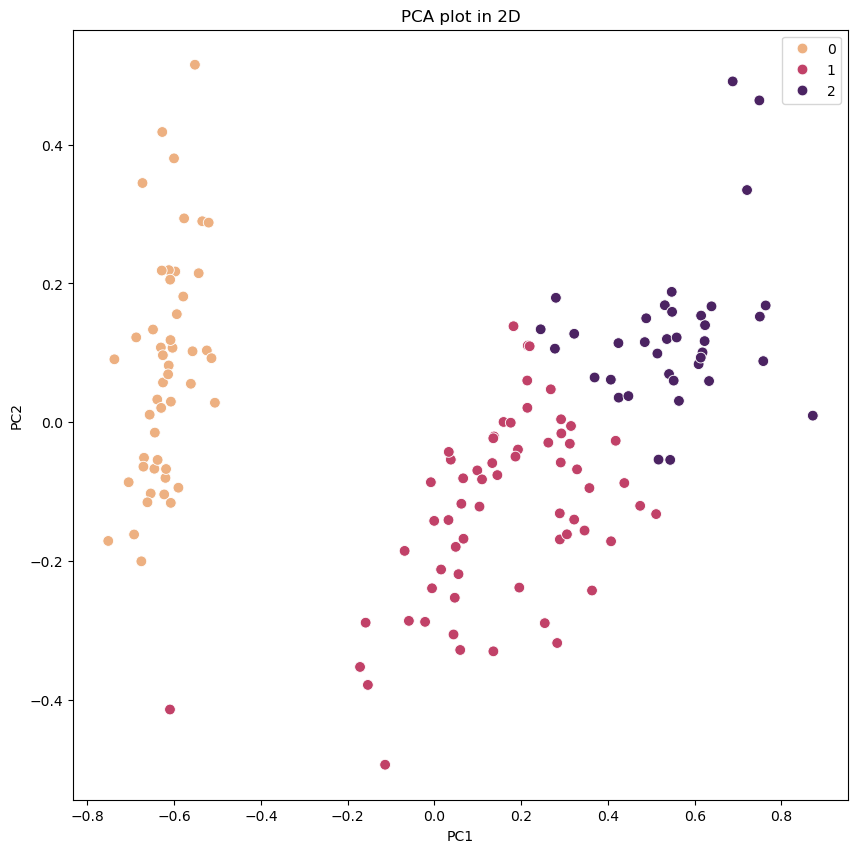

In [22]:
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_sp, 
                palette="flare", 
                s=60)
plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

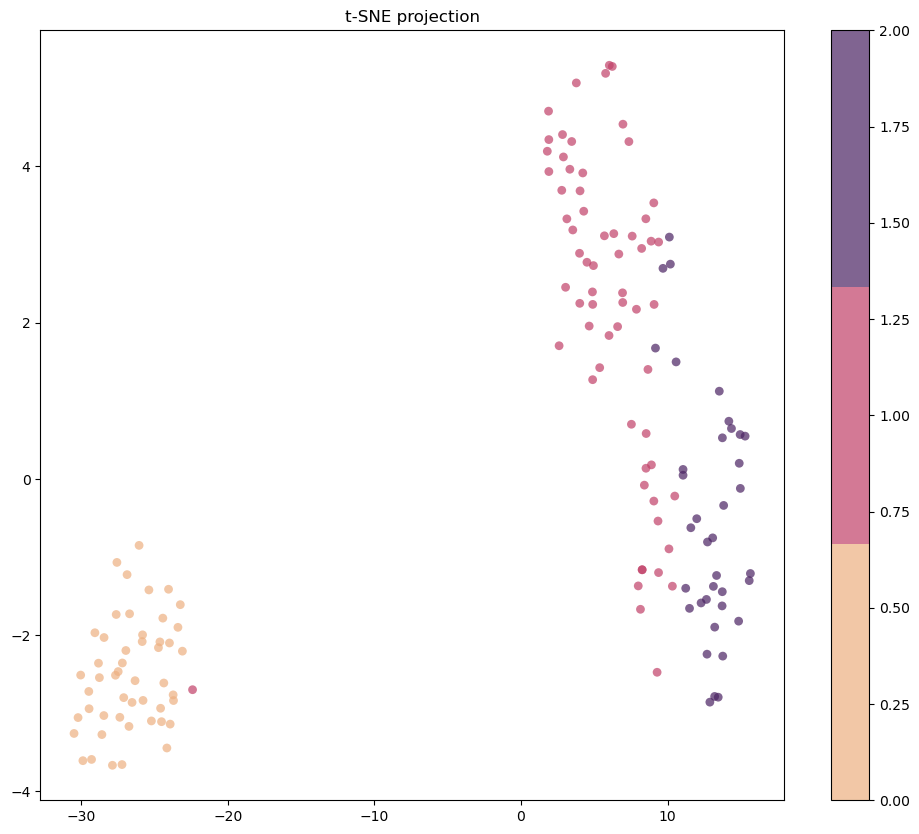

In [23]:
TSNEplot(pred_sp)

## Обзор целевой переменной

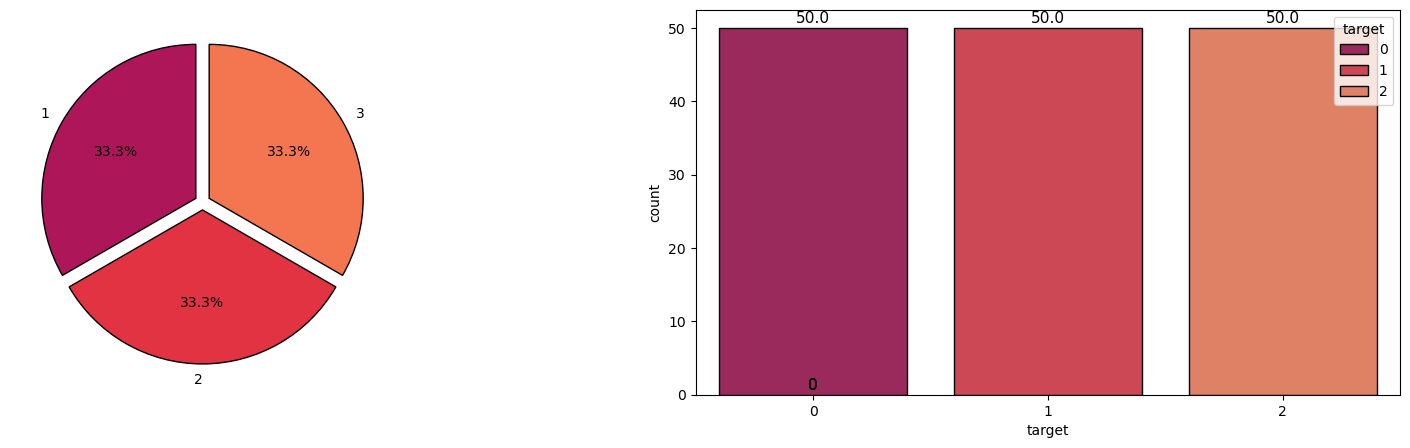

In [24]:
iris_df['target'] = iris.target
y = iris_df.iloc[:, 4]


l = list(iris_df['target'].value_counts())
sumLenn = sum(l)
proc = [l[1] / sumLenn * 100, l[0] / sumLenn * 100, l[2] / sumLenn * 100]
colors1 = sns.color_palette("rocket")[2:5]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (20, 5))
plt.subplot(1, 2, 1)
plt.pie(proc, labels = ['1', '2', '3'], 
        autopct = '%1.1f%%', 
        startangle = 90,
        explode = (0.05,0.05, 0.05), 
        colors = colors1, 
        wedgeprops = {'edgecolor' : 'black','antialiased' : True})

plt.subplot(1, 2, 2)
ax = sns.countplot(x = (iris_df['target']), 
                   hue = (iris_df['target']), 
                   palette = colors1, 
                   edgecolor = "black" )
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.7,\
            rect.get_height() , horizontalalignment='center', fontsize = 11)

# RAND_SCORE

In [25]:
rs_k = rand_score(kmeans.labels_, y) 
rs_ward = rand_score(pred_ward, y)
rs_sp = rand_score(pred_sp, y)

print('\nK-Means')
print('_'*45 + '\n')
print(" rand_score = {} \n\n {} из 150 предсказано верно \n\n\n\n".format(rs_k, rs_k * 150))


print('Agglomerative Clustering')
print('_'*45 + '\n')
print(" rand_score = {} \n\n {} из 150 предсказано верно \n\n\n\n".format(rs_ward, rs_ward * 150))


print('Spectral Clustering')
print('_'*45 + '\n')
print(" rand_score = {} \n\n {} из 150 предсказано верно \n".format(rs_sp, rs_sp * 150))


K-Means
_____________________________________________

 rand_score = 0.8679194630872483 

 130.18791946308724 из 150 предсказано верно 




Agglomerative Clustering
_____________________________________________

 rand_score = 0.8737360178970918 

 131.06040268456377 из 150 предсказано верно 




Spectral Clustering
_____________________________________________

 rand_score = 0.8314988814317673 

 124.7248322147651 из 150 предсказано верно 



## ACCURACY_SCORE

In [26]:
y = y*10

In [27]:
def ACCURACY_SCORE_MY_SOLUTION(pred, R, v):
    
    diff = y - pred
    bb_data = pd.DataFrame(pred.copy())
    diff = diff.apply(lambda x: 1 if (x in [v[0] - R[0], v[1] - R[1], v[2] - R[2]]) else 0)
    
    
    bb_data.replace(to_replace=R[0], value=v[0], inplace=True)
    bb_data.replace(to_replace=R[1], value=v[1], inplace=True)
    bb_data.replace(to_replace=R[2], value=v[2], inplace=True)

    
    acc_k = accuracy_score(bb_data, y) 
    print(" accuracy_score = {} \n\n {} значений из 150 предсказано верно \n\n\n\n".format(acc_k, acc_k * 150))
    
    
    principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(iris_df.iloc[:, :4]))
    components = PCA(n_components=3).fit_transform(iris_df.iloc[:, :4])

    
    fig = plt.figure(figsize=(10, 10))
    sns.scatterplot(x = principal_df.iloc[:,0], y = principal_df.iloc[:,1], hue = diff, palette=['#FF0000', '#1E90FF' ], s=90)
    plt.title('PCA график ошибок 2D')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

## K-Means

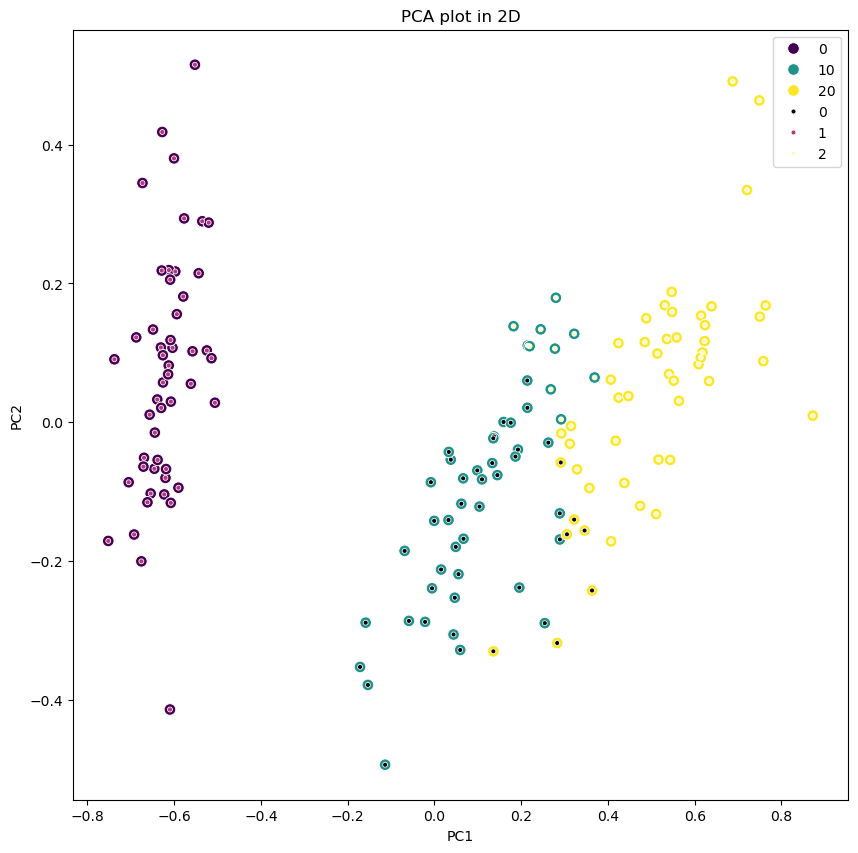

In [28]:
principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(iris_df.iloc[:, :4]))

fig = plt.figure(figsize=(10, 10))

sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = y,
                palette="viridis", 
                s=70)
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = kmeans.labels_, 
                palette="magma", 
                marker=".", 
                s=50)

plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

 accuracy_score = 0.5466666666666666 

 82.0 значений из 150 предсказано верно 






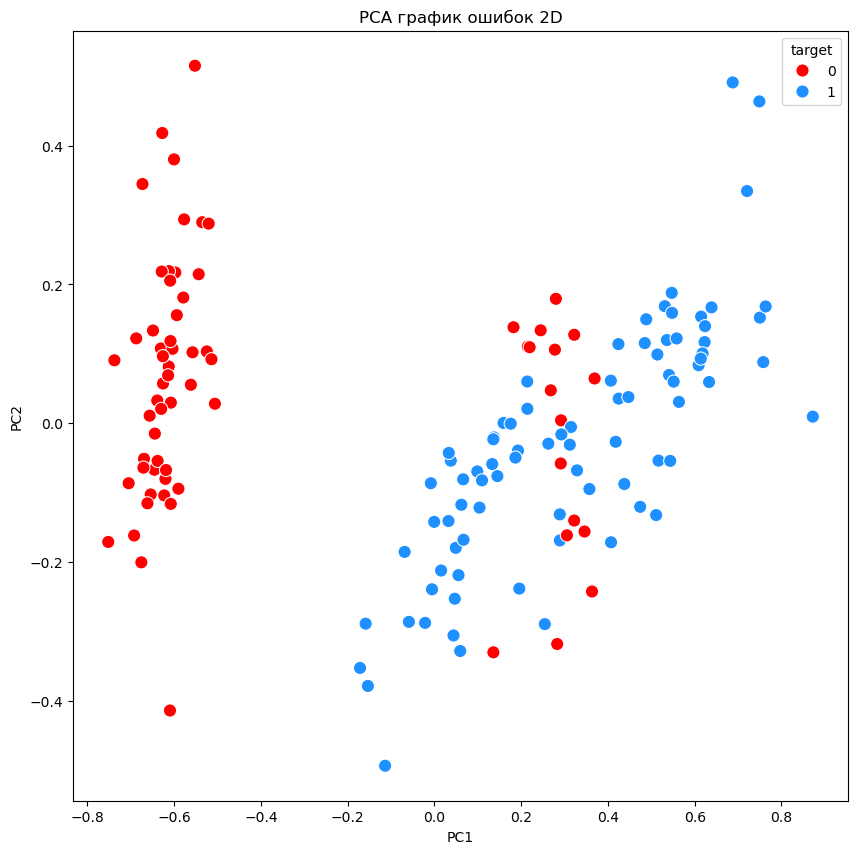

In [29]:
ACCURACY_SCORE_MY_SOLUTION(pred_k, [0,2,1], [10, 20, 30])

## Agglomerative Clustering by Ward

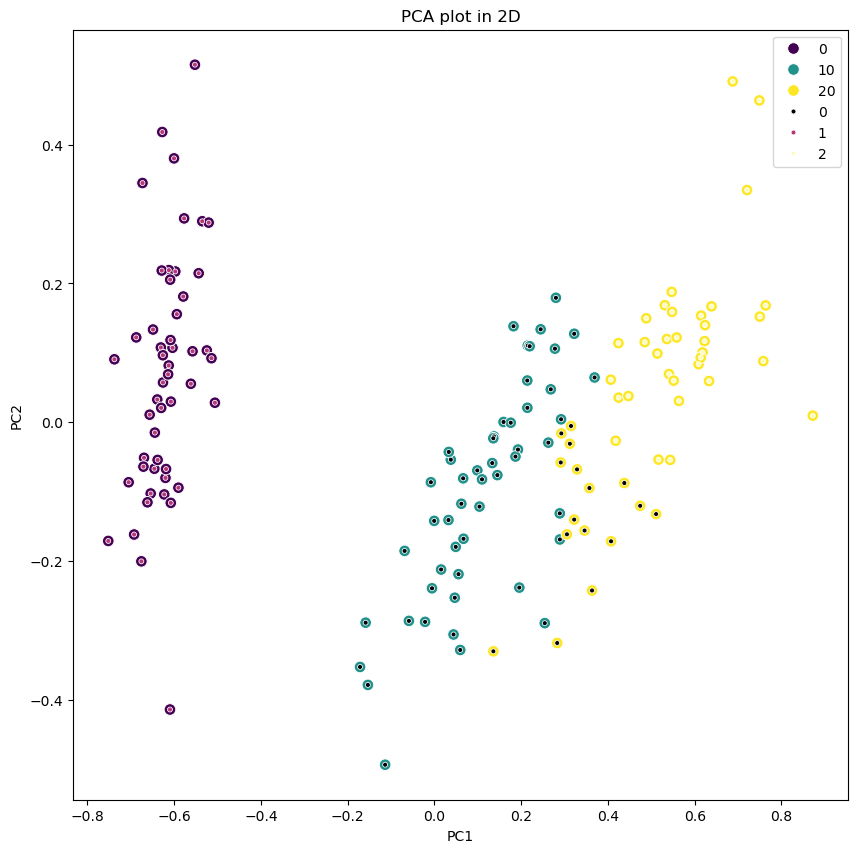

In [30]:
principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(iris_df.iloc[:, :4]))

fig = plt.figure(figsize=(10, 10))

sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = y, 
                palette="viridis", 
                s=70)
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_ward, 
                palette="magma", 
                marker=".", s=50)

plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

 accuracy_score = 0.11333333333333333 

 17.0 значений из 150 предсказано верно 






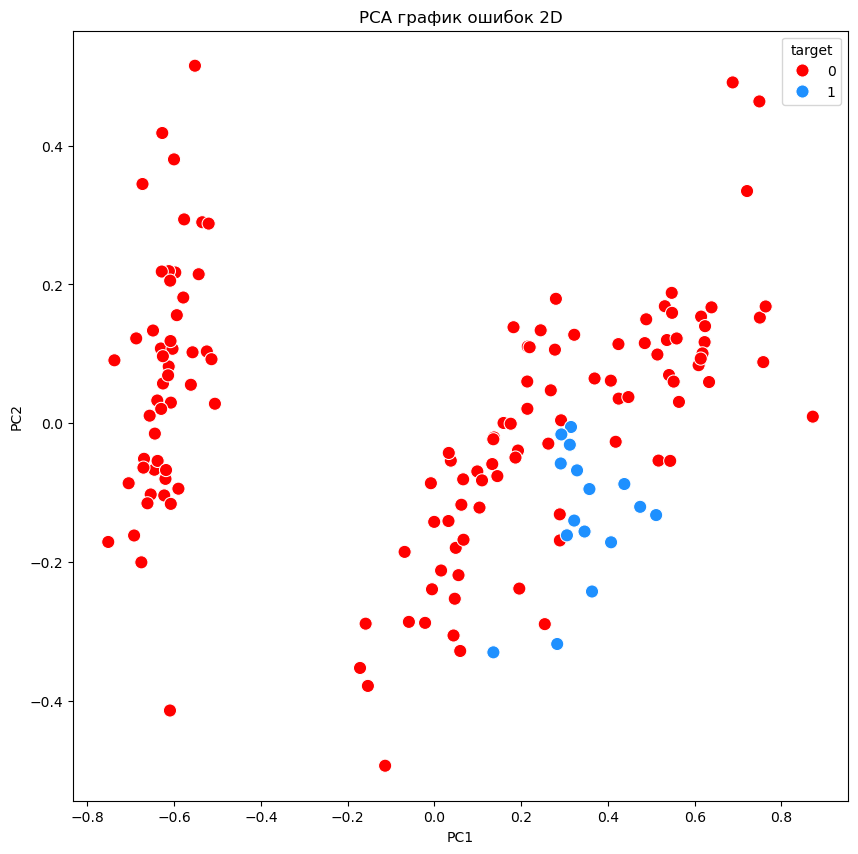

In [31]:
ACCURACY_SCORE_MY_SOLUTION(pred_ward, [2,0,1], [10, 20, 30])

## Spectral Clustering

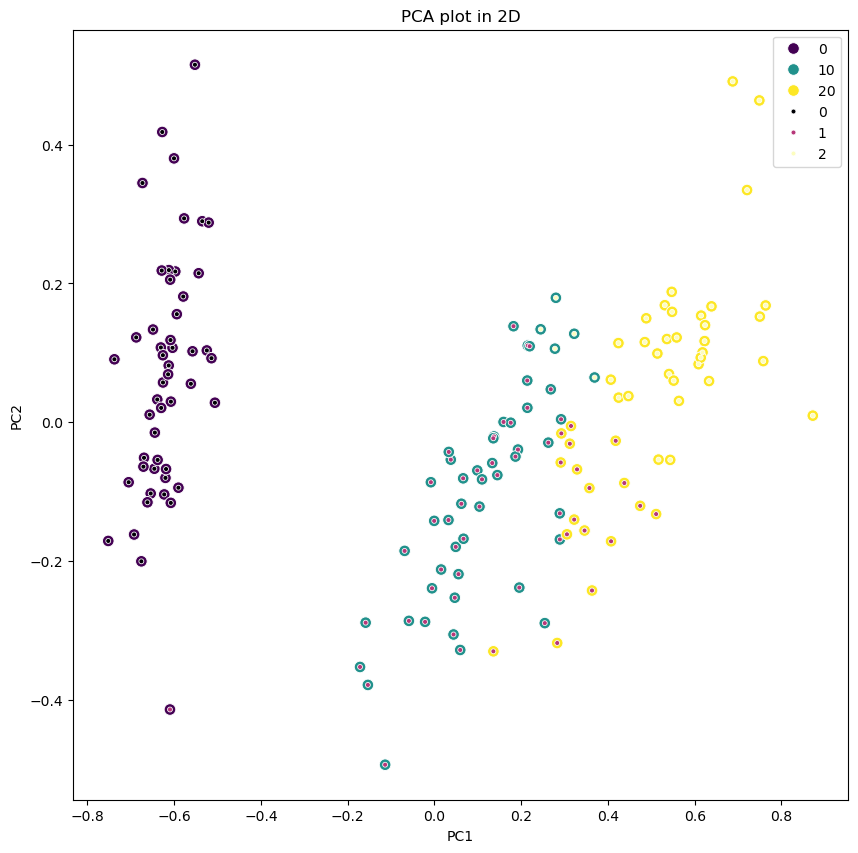

In [32]:
principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(iris_df.iloc[:, :4]))

fig = plt.figure(figsize=(10, 10))

sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = y, 
                palette="viridis", 
                s=70)
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_sp, 
                palette="magma", 
                marker=".", 
                s=50)

plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

## Распределение атрибутов реальных кластеров

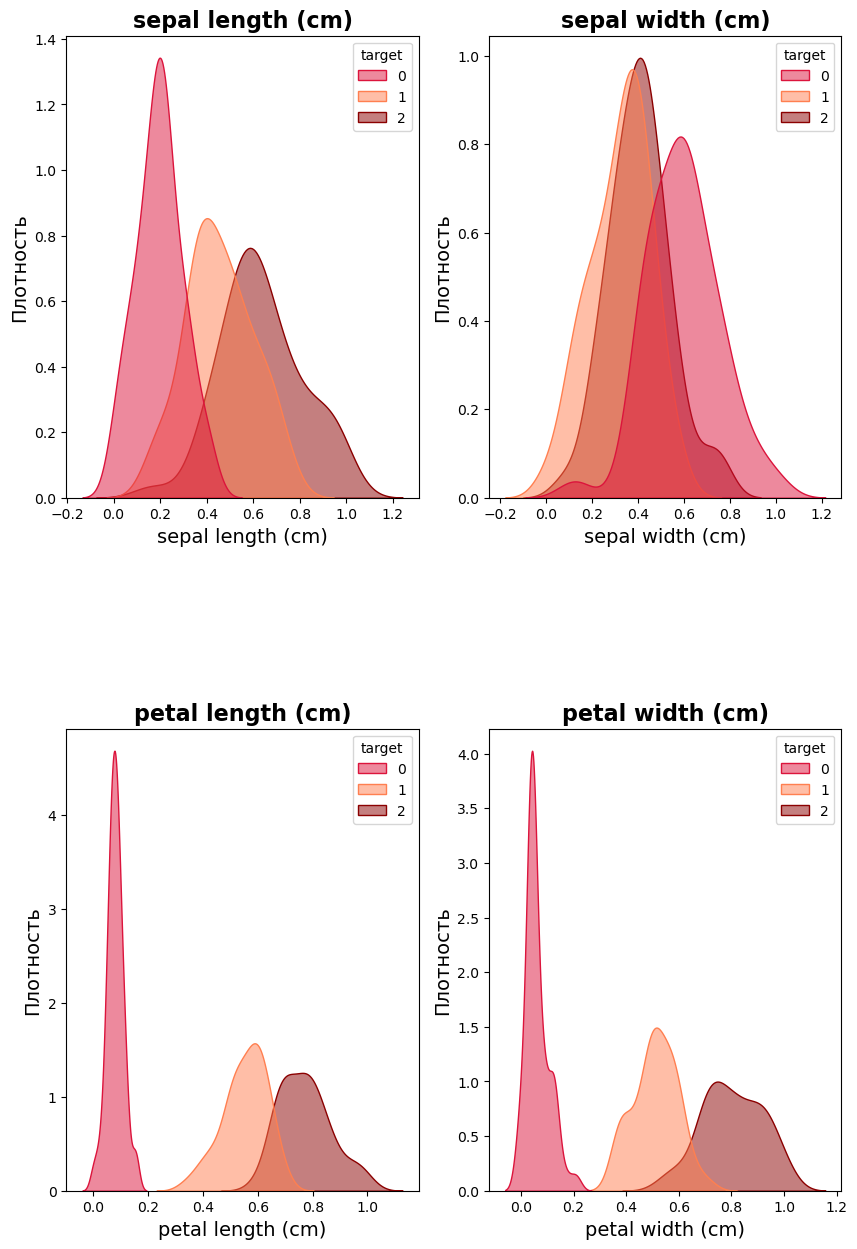

In [33]:
# Создаем матрицу графиков для визуализации распредления по каждой переменной
fig, axes = plt.subplots(2,2, figsize = (10,15))

# Расстояние между графиками
plt.subplots_adjust(hspace=0.5)

# Список значений признаков для цикла
columns = iris_df.columns[:4]

# Строим распределения (kdeplot) для каждого признака
for i, column in enumerate(columns):
    ax = axes[i // 2, i % 2]
    sns.kdeplot(data = iris_df,
                palette = ['#DC143C','#FF7F50','#8B0000'],
                x = column,
                fill = True,
                alpha = 0.5,
                hue = 'target',
                ax = ax)
    
    ax.set_title(column, fontweight = 'bold', fontsize = 16)
    ax.set_xlabel(column, fontsize = 14)
    ax.set_ylabel('Плотность', fontsize = 14)
    

plt.show()